# Research Question
Which MLB pitch types are most effective at limiting offensive production during the 2026 season?

In [2]:
# Loading the statcast_clean_2026.csv file into a pandas dataframe
import pandas as pd

statcast_clean = pd.read_csv("statcast_clean_2026.csv")

print(statcast_clean.shape)

(576199, 119)


In [3]:
# Checking what columns and data types are in the dataframe
print(statcast_clean.info())

<class 'pandas.DataFrame'>
RangeIndex: 576199 entries, 0 to 576198
Columns: 119 entries, pitch_type to intercept_ball_minus_batter_pos_y_inches
dtypes: float64(68), int64(34), str(17)
memory usage: 523.1 MB
None


In [4]:
# Checking what games we are dealing with in the dataframe
print(statcast_clean["game_type"].value_counts())

game_type
R    575939
A       260
Name: count, dtype: int64


In [5]:
# Checking what pitch types are in the dataframe
print(statcast_clean["pitch_name"].value_counts())

pitch_name
4-Seam Fastball    175581
Sinker              95626
Slider              75654
Changeup            64491
Sweeper             47713
Cutter              45603
Curveball           36762
Split-Finger        18540
Knuckle Curve        9176
Slurve               2605
Eephus                902
Other                 638
Forkball              379
Knuckleball           284
Slow Curve            113
Pitch Out              32
Unknown                10
Name: count, dtype: int64


In [6]:
# Filtering the dataframe to only include regular season games
statcast_regular = statcast_clean[
    statcast_clean["game_type"] == "R"
].copy()

print(statcast_regular.shape)

(575939, 119)


In [7]:
# Filtering out the main 8 pitch types I am using for the anaylsis. I am excluding the knuckleball, eephus, and other rare pitch types.
main_pitch_types = [
    "4-Seam Fastball",
    "Sinker",
    "Slider",
    "Changeup",
    "Sweeper",
    "Cutter",
    "Curveball",
    "Split-Finger"
]

statcast_analysis = statcast_regular[
    statcast_regular["pitch_name"].isin(main_pitch_types)
].copy()

print(statcast_analysis.shape)
print(statcast_analysis["pitch_name"].value_counts())

(559722, 119)
pitch_name
4-Seam Fastball    175506
Sinker              95580
Slider              75624
Changeup            64448
Sweeper             47697
Cutter              45580
Curveball           36757
Split-Finger        18530
Name: count, dtype: int64


In [8]:
# Checking for missing values in the important columns
important_columns = [
    "pitch_name",
    "pitcher",
    "game_date",
    "launch_speed",
    "events",
    "description"
]

print(statcast_analysis[important_columns].isna().sum())

pitch_name           0
pitcher              0
game_date            0
launch_speed    373697
events          415949
description          0
dtype: int64


In [9]:
# Checking how many batted balls are in the dataframe
batted_balls = statcast_analysis[
    statcast_analysis["launch_speed"].notna()
].copy()

print("Batted balls:", len(batted_balls))

Batted balls: 186025


In [10]:
# Calculating the average exit velocity for each pitcher and pitch type combination
exit_velocity = (
    batted_balls
    .groupby(["pitcher", "pitch_type"])
    .agg(
        avg_exit_velocity=("launch_speed", "mean"),
        batted_balls=("launch_speed", "count")
    )
    .reset_index()
)

print(exit_velocity.head())
print(exit_velocity.shape)

   pitcher pitch_type  avg_exit_velocity  batted_balls
0   434378         CH          85.780000             5
1   434378         CU          89.300000             5
2   434378         FF          89.669231            13
3   434378         SL          88.950000             8
4   434378         ST          91.900000             1
(3524, 4)


In [11]:
# Checking the distribution of launch speeds in the batted balls dataframe
print(batted_balls["launch_speed"].describe())

count    186025.000000
mean         82.537509
std          15.306348
min           3.500000
25%          73.100000
50%          82.300000
75%          94.400000
max         119.700000
Name: launch_speed, dtype: float64


In [12]:
# Checking the 20 lowest launch speeds in the batted balls dataframe
print(
    batted_balls[
        ["launch_speed", "pitch_name", "events"]
    ]
    .sort_values("launch_speed")
    .head(20)
)

        launch_speed       pitch_name     events
457091           3.5           Slider        NaN
175660           3.9           Slider        NaN
98895            4.0  4-Seam Fastball        NaN
10751            4.0           Sinker        NaN
238538           4.7  4-Seam Fastball        NaN
429258           4.9         Changeup        NaN
313359           5.2           Slider        NaN
62037            5.3  4-Seam Fastball        NaN
170267           5.4         Changeup        NaN
96603            5.9         Changeup        NaN
413565           6.3          Sweeper  field_out
96071            6.5           Sinker        NaN
7383             6.6  4-Seam Fastball        NaN
510553           6.8           Sinker        NaN
157834           7.0         Changeup        NaN
175851           7.0           Sinker        NaN
269020           7.2         Changeup        NaN
291607           7.4          Sweeper        NaN
513830           7.5           Cutter        NaN
292469           7.8

In [13]:
# Filtering the batted balls dataframe to only include rows with valid launch speeds and events
batted_balls = statcast_analysis[
    statcast_analysis["launch_speed"].notna() &
    statcast_analysis["events"].notna()
].copy()

print("Valid batted balls:", len(batted_balls))
print(batted_balls["launch_speed"].describe())

Valid batted balls: 97327
count    97327.000000
mean        88.040888
std         15.271895
min          6.300000
25%         79.900000
50%         91.100000
75%         99.300000
max        119.000000
Name: launch_speed, dtype: float64


In [14]:
# Recalculating the average exit velocity for each pitcher and pitch type combination with updated launch speed data including only valid launch speeds and events
exit_velocity = (
    batted_balls
    .groupby(["pitcher", "pitch_type"])
    .agg(
        avg_exit_velocity=("launch_speed", "mean"),
        batted_balls=("launch_speed", "count")
    )
    .reset_index()
)

print(exit_velocity.shape)
print(exit_velocity.head())

(3435, 4)
   pitcher pitch_type  avg_exit_velocity  batted_balls
0   434378         CH          94.800000             1
1   434378         CU          91.566667             3
2   434378         FF          94.157143             7
3   434378         SL          93.900000             4
4   434378         ST          91.900000             1


In [15]:
# Checking the unique pitch types and their corresponding pitch names in the statcast_analysis dataframe
print(statcast_analysis[["pitch_type", "pitch_name"]].drop_duplicates().sort_values("pitch_type"))

    pitch_type       pitch_name
6           CH         Changeup
20          CU        Curveball
14          FC           Cutter
3           FF  4-Seam Fastball
157         FS     Split-Finger
2           SI           Sinker
7           SL           Slider
0           ST          Sweeper


In [ ]:
# Merging the exit_velocity dataframe with the pitcher_id column from the statcast_analysis dataframe. 
# Changing the column name from "pitcher" to "pitcher_id" to match the statcast_analysis dataframe for merging purposes.
exit_velocity_merge = exit_velocity.rename(
    columns={"pitcher": "pitcher_id"}
)

print(exit_velocity_merge.head())

   pitcher_id pitch_type  avg_exit_velocity  batted_balls
0      434378         CH          94.800000             1
1      434378         CU          91.566667             3
2      434378         FF          94.157143             7
3      434378         SL          93.900000             4
4      434378         ST          91.900000             1


In [17]:
# Loading the pitch arsenal stats from Baseball Savant for the 2026 season
import requests
from io import StringIO

url = "https://baseballsavant.mlb.com/leaderboard/pitch-arsenal-stats?type=pitcher&year=2026&csv=true"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

pitch_data = pd.read_csv(StringIO(response.text))

print(pitch_data.shape)

(538, 20)


In [18]:
# Renaming columns in the pitch_data dataframe to match the column names in the statcast_analysis dataframe for merging purposes
pitch_data = pitch_data.rename(columns={
    'last_name, first_name': 'pitcher',
    'player_id': 'pitcher_id',
    'team_name_alt': 'team',
    'pitch_name': 'pitch',
    'run_value_per_100': 'run_value_100',
    'pitch_usage': 'usage_percent',
    'est_ba': 'xBA',
    'est_woba': 'xwOBA',
    'hard_hit_percent': 'hard_hit_percent'
})

print(pitch_data.columns.tolist())

['pitcher', 'pitcher_id', 'team', 'pitch_type', 'pitch', 'run_value_100', 'run_value', 'pitches', 'usage_percent', 'pa', 'ba', 'slg', 'woba', 'whiff_percent', 'k_percent', 'put_away', 'xBA', 'est_slg', 'xwOBA', 'hard_hit_percent']


In [19]:
# Filtering the pitch_data dataframe to only include rows with the main pitch types
pitch_data_main = pitch_data[
    pitch_data["pitch"].isin(main_pitch_types)
].copy()

print(pitch_data_main.shape)
print(pitch_data_main["pitch"].value_counts())

(535, 20)
pitch
4-Seam Fastball    209
Sinker             103
Slider              59
Changeup            49
Sweeper             37
Cutter              31
Curveball           27
Split-Finger        20
Name: count, dtype: int64


In [20]:
# Merging the pitch_data_main dataframe with the exit_velocity_merge dataframe on pitcher_id and pitch_type to create a new dataframe called analysis_data.
# Also checking how many pitcher/pitch combinations in the pitch_data_main dataframe do not have a corresponding average exit velocity in the exit_velocity_merge dataframe.
analysis_data = pitch_data_main.merge(
    exit_velocity_merge,
    on=["pitcher_id", "pitch_type"],
    how="left"
)

print(analysis_data.shape)
print(analysis_data["avg_exit_velocity"].isna().sum())

(535, 22)
7


In [ ]:
# Checking which of the 7 exit velocity values are missing in the analysis_data dataframe and printing the corresponding pitcher, pitch, pitch_type, pitches, and pa columns for those rows.
print(
    analysis_data[
        analysis_data["avg_exit_velocity"].isna()
    ][
        ["pitcher", "pitch", "pitch_type", "pitches", "pa"]
    ]
)

             pitcher      pitch pitch_type  pitches   pa
28        Baz, Shane  Curveball         CU      901  256
38       Nola, Aaron  Curveball         CU      907  246
131    Cavalli, Cade  Curveball         CU      723  178
198    Soriano, José  Curveball         CU      689  152
301   Freeland, Kyle  Curveball         CU      432  127
395      Burke, Sean  Curveball         CU      521  113
500  Pallante, Andre  Curveball         CU      412   93


In [22]:
# Checking the distribution of the metrics that will be used for "Effectiveness Score"
print(
    analysis_data[
        [
            "run_value_100",
            "whiff_percent",
            "woba",
            "xBA",
            "avg_exit_velocity",
            "k_percent",
            "hard_hit_percent"
        ]
    ].describe()
)

       run_value_100  whiff_percent        woba         xBA  \
count     535.000000     535.000000  535.000000  535.000000   
mean        0.383738      24.386916    0.315929    0.240564   
std         1.120350       9.504486    0.061320    0.046351   
min        -3.000000       5.100000    0.140000    0.089000   
25%        -0.300000      16.800000    0.274000    0.206000   
50%         0.400000      23.300000    0.313000    0.240000   
75%         1.100000      31.100000    0.355500    0.273000   
max         4.300000      54.500000    0.502000    0.386000   

       avg_exit_velocity   k_percent  hard_hit_percent  
count         528.000000  535.000000        535.000000  
mean           88.270956   22.809907         39.188037  
std             3.210078    9.606250          8.747839  
min            76.262887    2.500000         14.300000  
25%            86.298363   15.600000         33.700000  
50%            88.696111   22.000000         39.600000  
75%            90.614719   29.300

# Effectiveness Score - a single number created to summarize how effective each pitch type is across several different pitching outcomes
Higher Effectiveness Score = more effective at limiting offensive production
The metrics used
Metric	            What we want	        Why
Whiff %	              Higher ↑	         More swings and misses
K %	                  Higher ↑	         More strikeouts
wOBA	              Lower ↓	         Limits overall offensive production
xBA	                  Lower ↓	         Limits expected batting average
Exit Velocity         Lower ↓	         Allows weaker contact
Hard-Hit %	          Lower ↓	         Fewer balls hit very hard
Run Value/100         Lower ↓	         Produces less offensive value per 100 pitches




In [23]:
# Calculating z-score to standardize the metrics used for "Effectiveness Score" because the metrics are on different scales. 
# Also, I am excluding K% because it overlaps with Whiff%
metrics = {
    "run_value_100": "z_run_value",
    "whiff_percent": "z_whiff",
    "woba": "z_woba",
    "xBA": "z_xBA",
    "avg_exit_velocity": "z_exit_velocity",
    "hard_hit_percent": "z_hard_hit"
}

for metric, z_metric in metrics.items():
    analysis_data[z_metric] = (
        (analysis_data[metric] - analysis_data[metric].mean())
        / analysis_data[metric].std()
    )

# Reverse the metrics where lower values are better
analysis_data["z_run_value"] = -analysis_data["z_run_value"]
analysis_data["z_woba"] = -analysis_data["z_woba"]
analysis_data["z_xBA"] = -analysis_data["z_xBA"]
analysis_data["z_exit_velocity"] = -analysis_data["z_exit_velocity"]
analysis_data["z_hard_hit"] = -analysis_data["z_hard_hit"]

print(
    analysis_data[
        [
            "z_run_value",
            "z_whiff",
            "z_woba",
            "z_xBA",
            "z_exit_velocity",
            "z_hard_hit"
        ]
    ].head()
)


   z_run_value   z_whiff    z_woba     z_xBA  z_exit_velocity  z_hard_hit
0    -0.371546 -0.956066 -0.490393 -0.829224        -0.291533   -0.847291
1     0.521032 -0.871895 -0.718702 -0.807649        -0.997505   -0.812997
2    -1.085609  1.737399  1.075157  1.630260         0.178293    0.032927
3     0.431774 -1.292749 -1.256859 -1.541179        -1.588783   -1.441723
4     1.056579 -1.292749 -1.207936 -1.195989        -1.241020   -1.144507


In [24]:
# Calculating the "Effectiveness Score" by taking the average of the z-scores for each pitcher and pitch combination. The higher the score, the more effective the pitch is.
score_columns = [
    "z_run_value",
    "z_whiff",
    "z_woba",
    "z_xBA",
    "z_exit_velocity",
    "z_hard_hit"
]

analysis_data["effectiveness_score"] = (
    analysis_data[score_columns].mean(axis=1)
)

print(
    analysis_data[
        ["pitcher", "pitch", "effectiveness_score"]
    ].head(10)
)

               pitcher            pitch  effectiveness_score
0       Gausman, Kevin  4-Seam Fastball            -0.631009
1        Singer, Brady           Sinker            -0.614619
2   Misiorowski, Jacob  4-Seam Fastball             0.594738
3  Sánchez, Cristopher           Sinker            -1.114920
4       Abbott, Andrew  4-Seam Fastball            -0.837604
5      Peralta, Freddy  4-Seam Fastball            -0.466817
6         Bradley, Taj  4-Seam Fastball            -0.817048
7      Valdez, Framber           Sinker            -0.986587
8         Burns, Chase  4-Seam Fastball            -0.283667
9      Gore, MacKenzie  4-Seam Fastball            -0.218941


In [25]:
# Calculating the Effectiveness Score for each pitch type by taking the average of the effectiveness scores for each pitcher and pitch combination. The higher the score, the more effective the pitch type is.
pitch_type_scores = (
    analysis_data
    .groupby("pitch")
    .agg(
        average_effectiveness=("effectiveness_score", "mean"),
        pitcher_count=("pitcher", "count"),
        total_pitches=("pitches", "sum")
    )
    .reset_index()
    .sort_values("average_effectiveness", ascending=False)
)

print(pitch_type_scores)

             pitch  average_effectiveness  pitcher_count  total_pitches
1         Changeup               0.713152             49          25838
6     Split-Finger               0.646779             20          10936
7          Sweeper               0.645137             37          18314
2        Curveball               0.606700             27          14810
5           Slider               0.468500             59          32332
3           Cutter              -0.008301             31          15980
0  4-Seam Fastball              -0.291146            209         133915
4           Sinker              -0.524520            103          56541


In [26]:
# Calculating the metrics for each pitch type by taking the average of the metrics for each pitcher and pitch combination. The higher the score, the more effective the pitch type is.
pitch_type_metrics = (
    analysis_data
    .groupby("pitch")
    .agg(
        effectiveness_score=("effectiveness_score", "mean"),
        run_value_100=("run_value_100", "mean"),
        whiff_percent=("whiff_percent", "mean"),
        woba=("woba", "mean"),
        xBA=("xBA", "mean"),
        avg_exit_velocity=("avg_exit_velocity", "mean"),
        hard_hit_percent=("hard_hit_percent", "mean")
    )
    .sort_values("effectiveness_score", ascending=False)
)

print(pitch_type_metrics.round(3))

                 effectiveness_score  run_value_100  whiff_percent   woba  \
pitch                                                                       
Changeup                       0.713          0.433         32.351  0.272   
Split-Finger                   0.647          0.645         34.440  0.247   
Sweeper                        0.645          0.359         31.681  0.286   
Curveball                      0.607          0.000         33.930  0.279   
Slider                         0.469          0.546         35.215  0.290   
Cutter                        -0.008          0.645         22.200  0.327   
4-Seam Fastball               -0.291          0.204         21.514  0.336   
Sinker                        -0.525          0.613         13.809  0.341   

                   xBA  avg_exit_velocity  hard_hit_percent  
pitch                                                        
Changeup         0.223             84.467            28.655  
Split-Finger     0.215             85.940  

| Rank | Pitch               |      Score | What stands out                              |
| ---- | ------------------- | ---------: | -------------------------------------------- |
| 1    | **Changeup**        |  **0.713** | Strong across almost every metric            |
| 2    | **Split-Finger**    |  **0.647** | High whiff%, lowest wOBA                     |
| 3    | **Sweeper**         |  **0.645** | Low xBA and exit velocity                    |
| 4    | **Curveball**       |  **0.607** | Strong whiff%, xBA, and run value            |
| 5    | **Slider**          |  **0.469** | Very high whiff%, but weaker contact results |
| 6    | **Cutter**          | **-0.008** | Around average overall                       |
| 7    | **4-Seam Fastball** | **-0.291** | Higher exit velocity and hard-hit rate       |
| 8    | **Sinker**          | **-0.525** | Lowest whiff% and relatively high wOBA/xBA   |


In [ ]:
# Calculating a pitch-count weighted effectiveness score. Because we want to give more weight to pitches that are thrown more often, we will calculate a weighted average of the effectiveness scores for each pitch type, using the number of pitches thrown as the weight.
weighted_scores = (
    analysis_data
    .groupby("pitch")
    .apply(
        lambda x: (x["effectiveness_score"] * x["pitches"]).sum()
        / x["pitches"].sum()
    )
    .reset_index(name="weighted_score")
    .sort_values("weighted_score", ascending=False)
)

print(weighted_scores.round(3))

             pitch  weighted_score
1         Changeup           0.733
7          Sweeper           0.675
6     Split-Finger           0.668
2        Curveball           0.614
5           Slider           0.492
3           Cutter           0.008
0  4-Seam Fastball          -0.284
4           Sinker          -0.540


Effectiveness Score does not substantially change based off giving weight to more pitches thrown so I will keep the orignial metric.

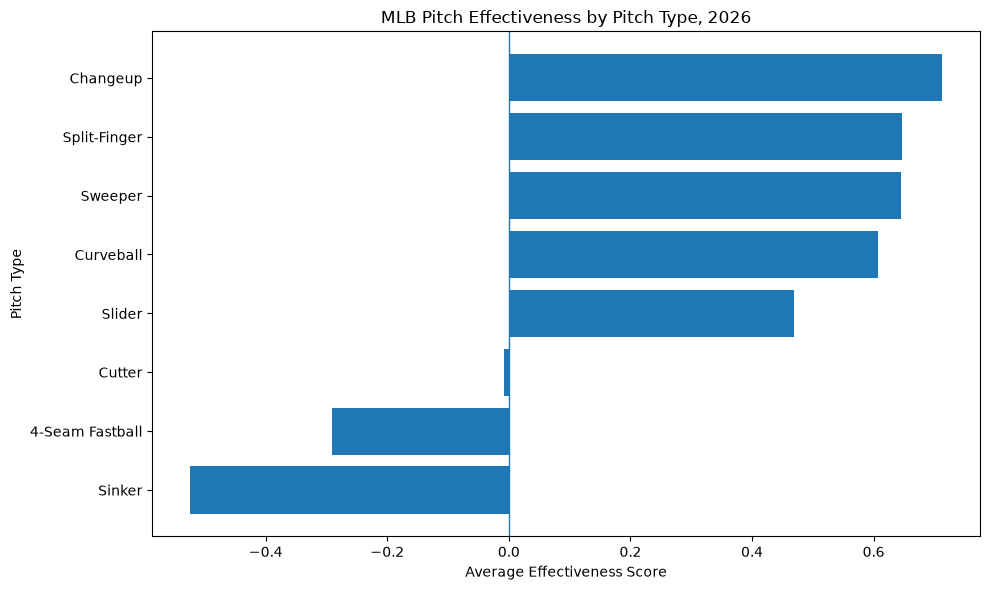

In [28]:
# Visualizing the average effectiveness score for each pitch type using a horizontal bar chart
import matplotlib.pyplot as plt

plot_data = pitch_type_scores.sort_values(
    "average_effectiveness",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["pitch"],
    plot_data["average_effectiveness"]
)

plt.xlabel("Average Effectiveness Score")
plt.ylabel("Pitch Type")
plt.title("MLB Pitch Effectiveness by Pitch Type, 2026")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.savefig("effectiveness_score.png", dpi=300, bbox_inches="tight")
plt.show()

The chart above compares the average Effectiveness Score for each pitch type. Changeups had the highest average score, while sinkers had the lowest. The zero line represents the overall average, making it easier to identify pitch types that performed above or below average.

In [29]:
# Create a table of the standardized metrics by pitch type

heatmap_data = (
    analysis_data
    .groupby("pitch")[
        [
            "z_run_value",
            "z_whiff",
            "z_woba",
            "z_xBA",
            "z_exit_velocity",
            "z_hard_hit"
        ]
    ]
    .mean()
)

# Rename columns for the visualization
heatmap_data.columns = [
    "Run Value",
    "Whiff Rate",
    "wOBA",
    "xBA",
    "Exit Velocity",
    "Hard-Hit Rate"
]

print(heatmap_data.round(2))

                 Run Value  Whiff Rate  wOBA   xBA  Exit Velocity  \
pitch                                                               
4-Seam Fastball       0.16       -0.30 -0.32 -0.09          -0.62   
Changeup             -0.04        0.84  0.72  0.38           1.19   
Curveball             0.34        1.00  0.60  0.76           0.52   
Cutter               -0.23       -0.23 -0.19 -0.28           0.44   
Sinker               -0.20       -1.11 -0.42 -0.82          -0.23   
Slider               -0.14        1.14  0.42  0.58           0.40   
Split-Finger         -0.23        1.06  1.12  0.55           0.73   
Sweeper               0.02        0.77  0.49  0.72           0.91   

                 Hard-Hit Rate  
pitch                           
4-Seam Fastball          -0.57  
Changeup                  1.20  
Curveball                 0.41  
Cutter                    0.44  
Sinker                   -0.37  
Slider                    0.42  
Split-Finger              0.66  
Sweeper     

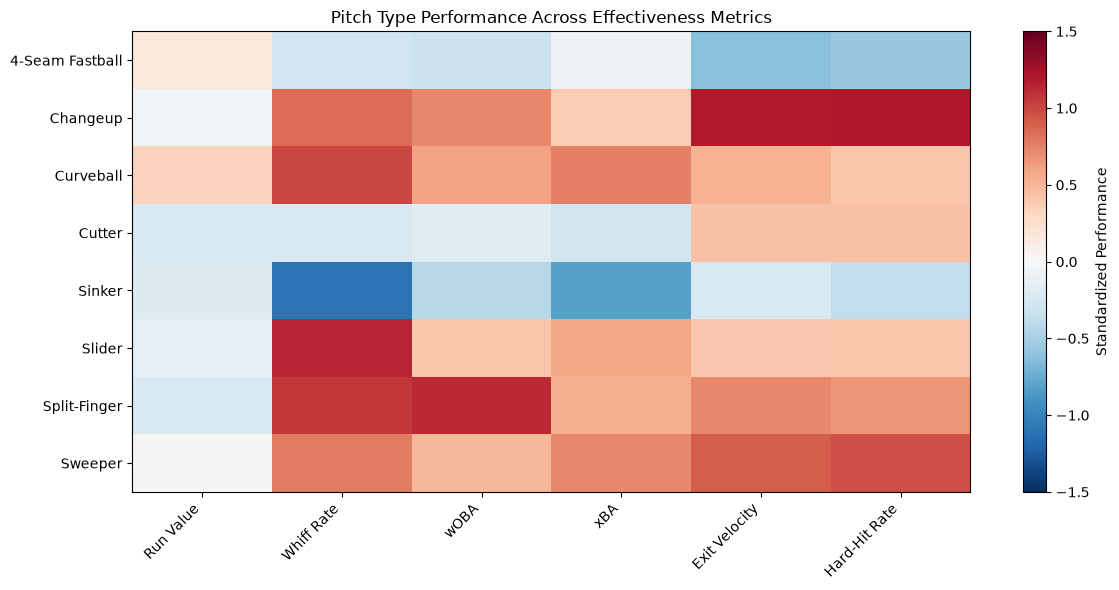

In [31]:
# Visualizing the standardized metrics by pitch type using a heatmap

plt.figure(figsize=(12, 6))

plt.imshow(
    heatmap_data,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-1.5,
    vmax=1.5
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.colorbar(label="Standardized Performance")

plt.title("Pitch Type Performance Across Effectiveness Metrics")
plt.tight_layout()
plt.savefig("pitch_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

The heatmap shows how each pitch type performed across the individual metrics used to calculate the Effectiveness Score.

Changeups performed well across several measures, including whiff rate, wOBA, expected batting average, exit velocity, and hard-hit rate. Sinkers had the lowest whiff rate at approximately 13.8% and also had relatively high wOBA and expected batting average, which contributed to their lower overall effectiveness score.

Interestingly, sliders had the highest average whiff rate at approximately 35.2%, but they did not rank first overall. This demonstrates why I used multiple measures instead of relying on a single statistic when evaluating pitch effectiveness.

# AI assistance:
 ChatGPT-5.6 Luna was used to help troubleshoot code,
 explain Python concepts, and suggest data-cleaning
 and visualization approaches